# Model Comparison: EOFlow vs scVI vs scGen vs Means

Loads all four trained models against the same held-out `key` condition and lines up ROC, MMD, mean-expression, effect-size, and violin-plot diagnostics into 2x2 grids so they can be compared directly.

## 0. Imports

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

import scgen

from src.model.VAE.VAE_model import MixturePriorSCVI, SCVIMixturePriorWrapper, assign_cluster_idx
from src.model.SCGEN.SCGEN_model import SCGENMixturePriorWrapper
from src.model.Mean.Mean_model import MeanShifter
from src.model.data_utils import (
    load_data,
    get_condition_vocab,
    split_holdout_combinations,
    load_metacells,
    copy_with_log_transform,
)

from src.analysis.analysis_utils import Analyzer, get_model_from_checkpoint
from src.analysis.logistic_regression import (
    generate_counterfactuals,
    generate_counterfactuals_scvi,
    generate_counterfactuals_scgen,
    generate_counterfactuals_mean,
    evaluate_cf_roc,
)
from src.analysis.mmd import (
    ctrl_mmd_dists,
    mmd_dists,
    plot_mmd_dists,
    global_mmd_by_key,
    plot_global_mmd_boxplot,
)
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_effect_size_comparison,
    plot_top_deg_violin,
)
from src.analysis.INN_OOD import (
    sample_leftout_combo_normal as inn_sample_leftout_combo_normal,
    sample_leftout_combo_shift as inn_sample_leftout_combo_shift,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
)
from src.analysis.Mean_OOD import (
    sample_leftout_combo_normal as mean_sample_leftout_combo_normal,
    sample_leftout_combo_shift as mean_sample_leftout_combo_shift,
)

## 1. Config

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
key = "CT-1"

comparison_dir = "/home/jhoefer/sandbox/results/comparison"
plot_dir = os.path.join(comparison_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

## 2. Load Models

In [3]:
USE_METACELLS = True

combo_conditions = ["cytokine", "cell_type"]
HOLDOUT_COMBO = {"cytokine": "IL-2", "cell_type": "CD8 Memory"}

if HOLDOUT_COMBO is not None:
    assert USE_METACELLS, "Holding out a combo requires USE_METACELLS=True."

In [ ]:
# All four sections below (2.1-2.4) load the same underlying data - same dataset,
# top_genes, and cell filtering/donors (and, when USE_METACELLS, group_keys) - just
# at different log_transform. Load the shared raw-count base once here and let each
# section take a cheap copy_with_log_transform() of it, instead of separately
# reloading four times: load_metacells's own on-disk cache already avoids re-running
# SEACells, but still re-reads that cache file from disk each time; load_data with
# USE_METACELLS=False has no caching at all and would otherwise reprocess the
# multi-GB source h5ad from scratch four times.
metacell_dataset_name = "parse"
metacell_top_genes = 2000
metacell_donors = ["Donor1"]
metacell_group_keys = ["cell_type", "cytokine"]

if USE_METACELLS:
    base_adata, base_labels_key, base_control_label = load_metacells(
        metacell_dataset_name,
        metacell_top_genes,
        metacell_group_keys,
        donors=metacell_donors,
        log_transform=False,
    )
else:
    base_adata, base_labels_key, base_control_label = load_data(
        metacell_dataset_name,
        metacell_top_genes,
        log_transform=False,
        cell_types=["CD4 Memory"],
    )

### 2.1 EOFlow

In [ ]:
eoflow_dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 0.1,
    "lam_MTC": 0.3,
    "use_counts": False,
}

eoflow_prefix = "1e-5_" if USE_METACELLS else ""
eoflow_adata = copy_with_log_transform(base_adata, log_transform=True)
eoflow_labels_key, eoflow_control_label = base_labels_key, base_control_label

eoflow_dataset_name = eoflow_dataset_args["dataset_name"]
eoflow_top_genes = min(eoflow_dataset_args["top_genes"], eoflow_adata.shape[1])
eoflow_sigma_noise = eoflow_dataset_args["sigma_noise"]
eoflow_lam_MTC = eoflow_dataset_args["lam_MTC"]

eoflow_model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", eoflow_dataset_name, "top_" + str(eoflow_top_genes)
)
eoflow_model_name = (
    eoflow_prefix
    + "MTC_"
    + str(eoflow_lam_MTC)
    + "_sigma_"
    + str(eoflow_sigma_noise)
    + "_model.pt"
)

if eoflow_dataset_args["use_counts"]:
    eoflow_model_path += "_counts"

if HOLDOUT_COMBO is None:
    eoflow_output_dir_path = os.path.join(
        "/home/jhoefer/sandbox/results", eoflow_dataset_name, "top_" + str(eoflow_top_genes)
    )
    eoflow_output_dir_name = (
        eoflow_prefix + "MTC_" + str(eoflow_lam_MTC) + "_sigma_" + str(eoflow_sigma_noise)
    )
    if eoflow_dataset_args["use_counts"]:
        eoflow_output_dir_path += "_counts"

    eoflow_model_path += "_best"
    eoflow_output_dir_path += "_best"

    eoflow_plot_dir = os.path.join(eoflow_output_dir_path, "plots", eoflow_output_dir_name)
    eoflow_csv_dir = os.path.join(eoflow_output_dir_path, "csv", eoflow_output_dir_name)
else:
    combo_str = "_".join(f"{k}-{v.replace(' ', '-')}" for k, v in HOLDOUT_COMBO.items())
    eoflow_model_path += f"_metacells_holdout_{combo_str}"

    eoflow_plot_dir = os.path.join(comparison_dir, "ood_eoflow", "plots")
    eoflow_csv_dir = os.path.join(comparison_dir, "ood_eoflow", "csv")

os.makedirs(eoflow_plot_dir, exist_ok=True)
os.makedirs(eoflow_csv_dir, exist_ok=True)

eoflow_checkpoint_path = os.path.join(eoflow_model_path, eoflow_model_name)

eoflow_model, _, eoflow_metrics_loss, eoflow_val_metrics_loss, eoflow_model_config = (
    get_model_from_checkpoint(eoflow_checkpoint_path, device)
)

eoflow_analyzer = Analyzer(
    eoflow_adata,
    eoflow_model,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    eoflow_labels_key,
    eoflow_control_label,
    eoflow_plot_dir,
    eoflow_csv_dir,
    checkpoint_path=eoflow_checkpoint_path,
    metrics_loss=eoflow_metrics_loss,
    conditions=[eoflow_labels_key],
    condition_type=eoflow_model_config.condition_type,
    val_metrics_loss=eoflow_val_metrics_loss,
)

if HOLDOUT_COMBO is not None:
    eoflow_combo_conditions = [eoflow_labels_key, "cell_type"]
    eoflow_holdout_combo = eoflow_model_config.holdout_combos[0]
    eoflow_combo_categories = eoflow_model_config.combo_categories
    print(f"EOFlow OOD holdout combo: {eoflow_holdout_combo}")

### 2.2 scVI

In [ ]:
scvi_beta = 0.01
scvi_lr_means = 1e-5

scvi_adata = copy_with_log_transform(base_adata, log_transform=False)
scvi_labels_key, scvi_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    scvi_adata.obs["cluster_idx"] = scvi_adata.obs[scvi_labels_key].astype("category").cat.codes
    scvi_train_adata = scvi_adata
    scvi_conditions = [scvi_labels_key]
    scvi_model_path = "/g/stegle/jhoefer/models/cvae"
    scvi_plot_dir = os.path.join(comparison_dir, "scvi", "plots")
    scvi_csv_dir = os.path.join(comparison_dir, "scvi", "csv")
else:
    scvi_condition_categories, scvi_combo_categories = get_condition_vocab(
        scvi_adata, combo_conditions
    )
    scvi_train_adata, _ = split_holdout_combinations(
        scvi_adata, [HOLDOUT_COMBO], group_keys=combo_conditions
    )
    assign_cluster_idx(
        scvi_train_adata, conditions=combo_conditions, combo_categories=scvi_combo_categories
    )
    scvi_conditions = combo_conditions

    combo_str = "_".join(f"{k}-{v.replace(' ', '-')}" for k, v in HOLDOUT_COMBO.items())
    scvi_model_path = f"/g/stegle/jhoefer/models/cvae/holdout_{combo_str}"
    scvi_plot_dir = os.path.join(comparison_dir, "ood_scvi", "plots")
    scvi_csv_dir = os.path.join(comparison_dir, "ood_scvi", "csv")

scvi_model = MixturePriorSCVI.load(
    scvi_model_path, adata=scvi_train_adata, prefix=f"{scvi_beta}_beta_{scvi_lr_means}_lr_means_"
)
scvi_wrapper = SCVIMixturePriorWrapper(scvi_model).to(device)

os.makedirs(scvi_plot_dir, exist_ok=True)
os.makedirs(scvi_csv_dir, exist_ok=True)

scvi_analyzer = Analyzer(
    scvi_adata,
    scvi_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scvi_labels_key,
    scvi_control_label,
    scvi_plot_dir,
    scvi_csv_dir,
    checkpoint_path=scvi_model_path,
    conditions=scvi_conditions,
    condition_type="mixture",
)

if HOLDOUT_COMBO is not None:
    scvi_holdout_combo = HOLDOUT_COMBO
    print(f"scVI OOD holdout combo: {scvi_holdout_combo}")

### 2.3 scGen

In [ ]:
scgen_adata = copy_with_log_transform(base_adata, log_transform=False)
scgen_labels_key, scgen_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    scgen_train_adata = scgen_adata
    scgen_conditions = [scgen_labels_key]
    scgen_combo_categories = None
    scgen_model_path = "/g/stegle/jhoefer/models/scgen"
    scgen_plot_dir = os.path.join(comparison_dir, "scgen", "plots")
    scgen_csv_dir = os.path.join(comparison_dir, "scgen", "csv")
else:
    scgen_adata.obs["cluster_idx"] = scgen_adata.obs[scgen_labels_key].astype("category").cat.codes
    scgen_condition_categories, scgen_combo_categories = get_condition_vocab(
        scgen_adata, combo_conditions
    )
    scgen_train_adata, _ = split_holdout_combinations(
        scgen_adata, [HOLDOUT_COMBO], group_keys=combo_conditions
    )
    scgen_conditions = combo_conditions

    combo_str = "_".join(f"{k}-{v.replace(' ', '-')}" for k, v in HOLDOUT_COMBO.items())
    scgen_model_path = f"/g/stegle/jhoefer/models/scgen/holdout_{combo_str}"
    scgen_plot_dir = os.path.join(comparison_dir, "ood_scgen", "plots")
    scgen_csv_dir = os.path.join(comparison_dir, "ood_scgen", "csv")

scgen_model = scgen.SCGEN.load(os.path.join(scgen_model_path, "model.pt"), adata=scgen_train_adata)
scgen_wrapper = SCGENMixturePriorWrapper(
    scgen_model,
    scgen_train_adata,
    scgen_labels_key,
    conditions=scgen_conditions,
    combo_categories=scgen_combo_categories,
)

os.makedirs(scgen_plot_dir, exist_ok=True)
os.makedirs(scgen_csv_dir, exist_ok=True)

scgen_analyzer = Analyzer(
    scgen_adata,
    scgen_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scgen_labels_key,
    scgen_control_label,
    scgen_plot_dir,
    scgen_csv_dir,
    checkpoint_path=None,
    conditions=scgen_conditions,
    condition_type=None,
)

if HOLDOUT_COMBO is not None:
    scgen_holdout_combo = HOLDOUT_COMBO
    print(f"scGen OOD holdout combo: {scgen_holdout_combo}")

### 2.4 Means

In [ ]:
mean_adata = copy_with_log_transform(base_adata, log_transform=True)
mean_labels_key, mean_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    mean_train_adata = mean_adata
    mean_conditions = None
    mean_plot_dir = os.path.join(comparison_dir, "mean", "plots")
    mean_csv_dir = os.path.join(comparison_dir, "mean", "csv")
else:
    mean_train_adata, _ = split_holdout_combinations(
        mean_adata, [HOLDOUT_COMBO], group_keys=combo_conditions
    )
    mean_conditions = combo_conditions
    mean_plot_dir = os.path.join(comparison_dir, "ood_mean", "plots")
    mean_csv_dir = os.path.join(comparison_dir, "ood_mean", "csv")

MeanShifter.setup_anndata(mean_train_adata, mean_labels_key, mean_control_label)
mean_shifter = MeanShifter(mean_train_adata)
mean_shifter.train()

os.makedirs(mean_plot_dir, exist_ok=True)
os.makedirs(mean_csv_dir, exist_ok=True)

mean_analyzer = Analyzer(
    mean_adata,
    mean_shifter,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    mean_labels_key,
    mean_control_label,
    mean_plot_dir,
    mean_csv_dir,
    checkpoint_path=None,
    conditions=mean_conditions,
)

if HOLDOUT_COMBO is not None:
    mean_holdout_combo = HOLDOUT_COMBO
    print(f"Means OOD holdout combo: {mean_holdout_combo}")

### 2.5 Registry

In [ ]:
models = [
    {
        "name": "EOFlow",
        "analyzer": eoflow_analyzer,
        "cf_fn": generate_counterfactuals,
        "log1p_transform": False,
    },
    {
        "name": "scVI",
        "analyzer": scvi_analyzer,
        "cf_fn": generate_counterfactuals_scvi,
        "log1p_transform": False,
    },
    {
        "name": "scGen",
        "analyzer": scgen_analyzer,
        "cf_fn": generate_counterfactuals_scgen,
        "log1p_transform": False,
    },
    {
        "name": "Means",
        "analyzer": mean_analyzer,
        "cf_fn": generate_counterfactuals_mean,
        "log1p_transform": False,
    },
]

## 3. Comparison Plots

### 3.1 ROC Curves

100%|████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.34it/s]

Best Validation Accuracy: 0.9636
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

100%|████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.34it/s]

Best Validation Accuracy: 0.9588
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.34it/s]


Best Validation Accuracy: 0.9928


100%|████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.34it/s]


Best Validation Accuracy: 0.6793


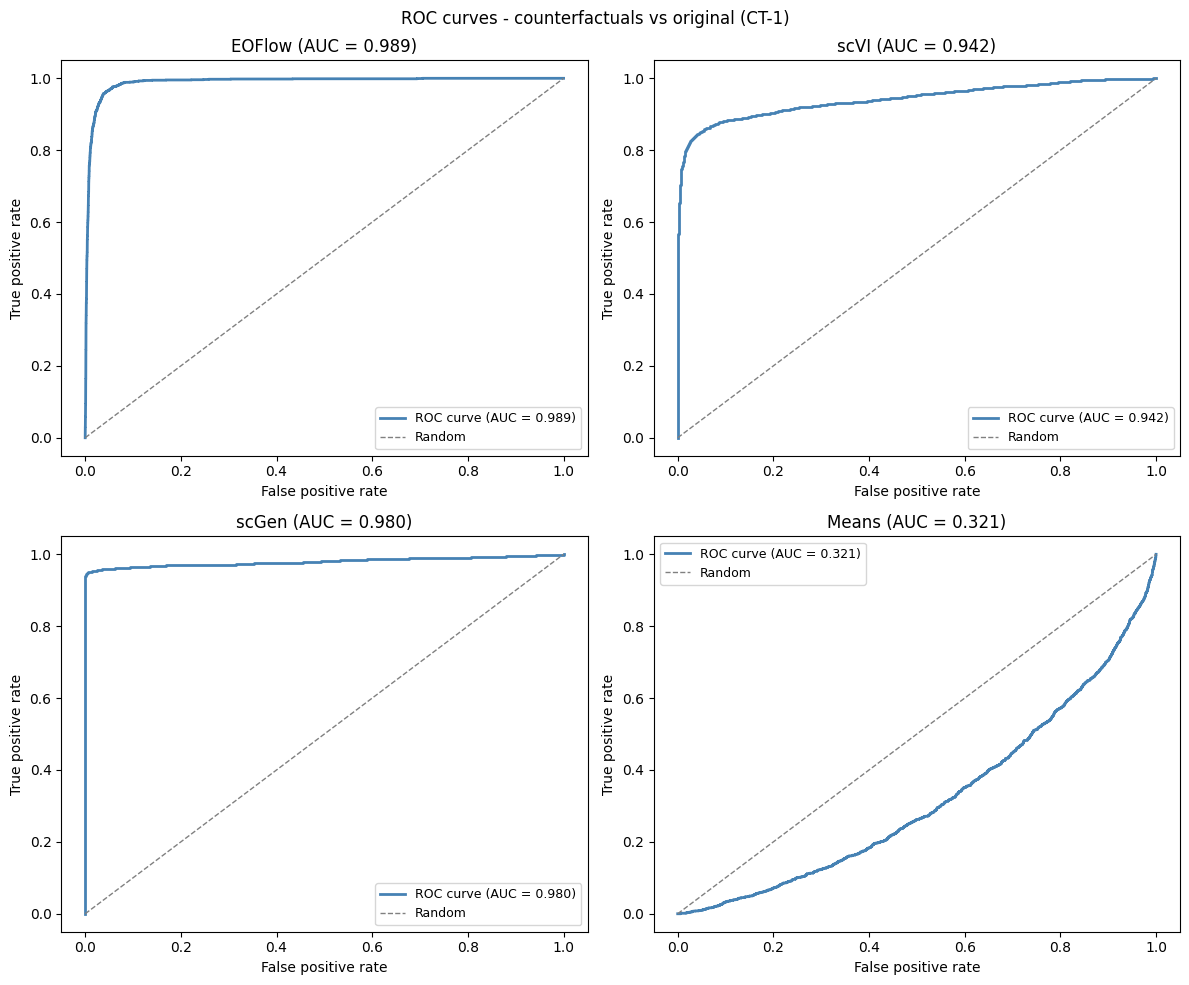

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for m, ax in zip(models, axes.flat):
    _, _, roc_auc = evaluate_cf_roc(m["analyzer"], key=key, cf_fn=m["cf_fn"], num_epochs=10, ax=ax)
    ax.set_title(f"{m['name']} (AUC = {roc_auc:.3f})")
fig.suptitle(f"ROC curves - counterfactuals vs original ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"roc_comparison_{key}.png"), dpi=300)
plt.show()

### 3.2 MMD

100%|████████████████████████████████████████████████████████████| 11/11 [00:26<00:00,  2.40s/it]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

100%|████████████████████████████████████████████████████████████| 11/11 [00:26<00:00,  2.40s/it]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


100%|████████████████████████████████████████████████████████████| 11/11 [00:26<00:00,  2.41s/it]


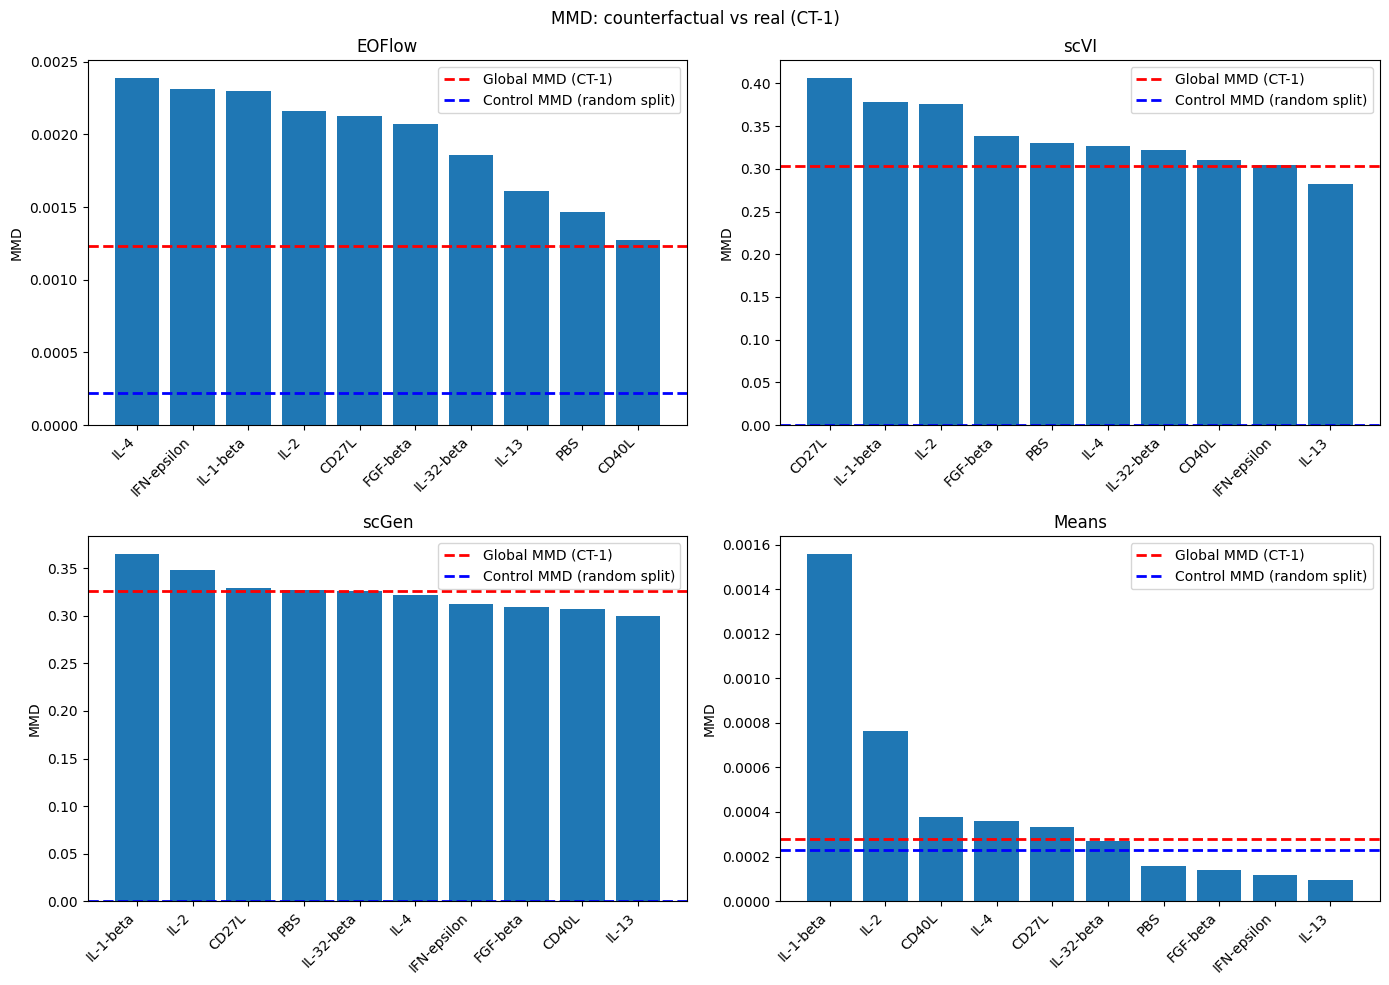

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    analyzer = m["analyzer"]
    ctrl_mmd = ctrl_mmd_dists(analyzer, key=key, log1p_transform=m["log1p_transform"])
    global_mmd, mmd_per_group = mmd_dists(
        analyzer, key=key, sigma=1.0, cf_fn=m["cf_fn"], log1p_transform=m["log1p_transform"]
    )
    plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key, ax=ax)
    ax.set_title(m["name"])
fig.suptitle(f"MMD: counterfactual vs real ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mmd_comparison_{key}.png"), dpi=300)
plt.show()

### 3.2b Global MMD Across All Held-Out Keys

Repeats the global-MMD computation from 3.2 for every held-out cytokine key (not just `key`), for each method, and summarizes the resulting distributions as a box plot.

In [ ]:
global_mmd_all_keys = global_mmd_by_key(models)

plot_global_mmd_boxplot(global_mmd_all_keys, plot_dir=plot_dir)

### 3.3 Mean Expression

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


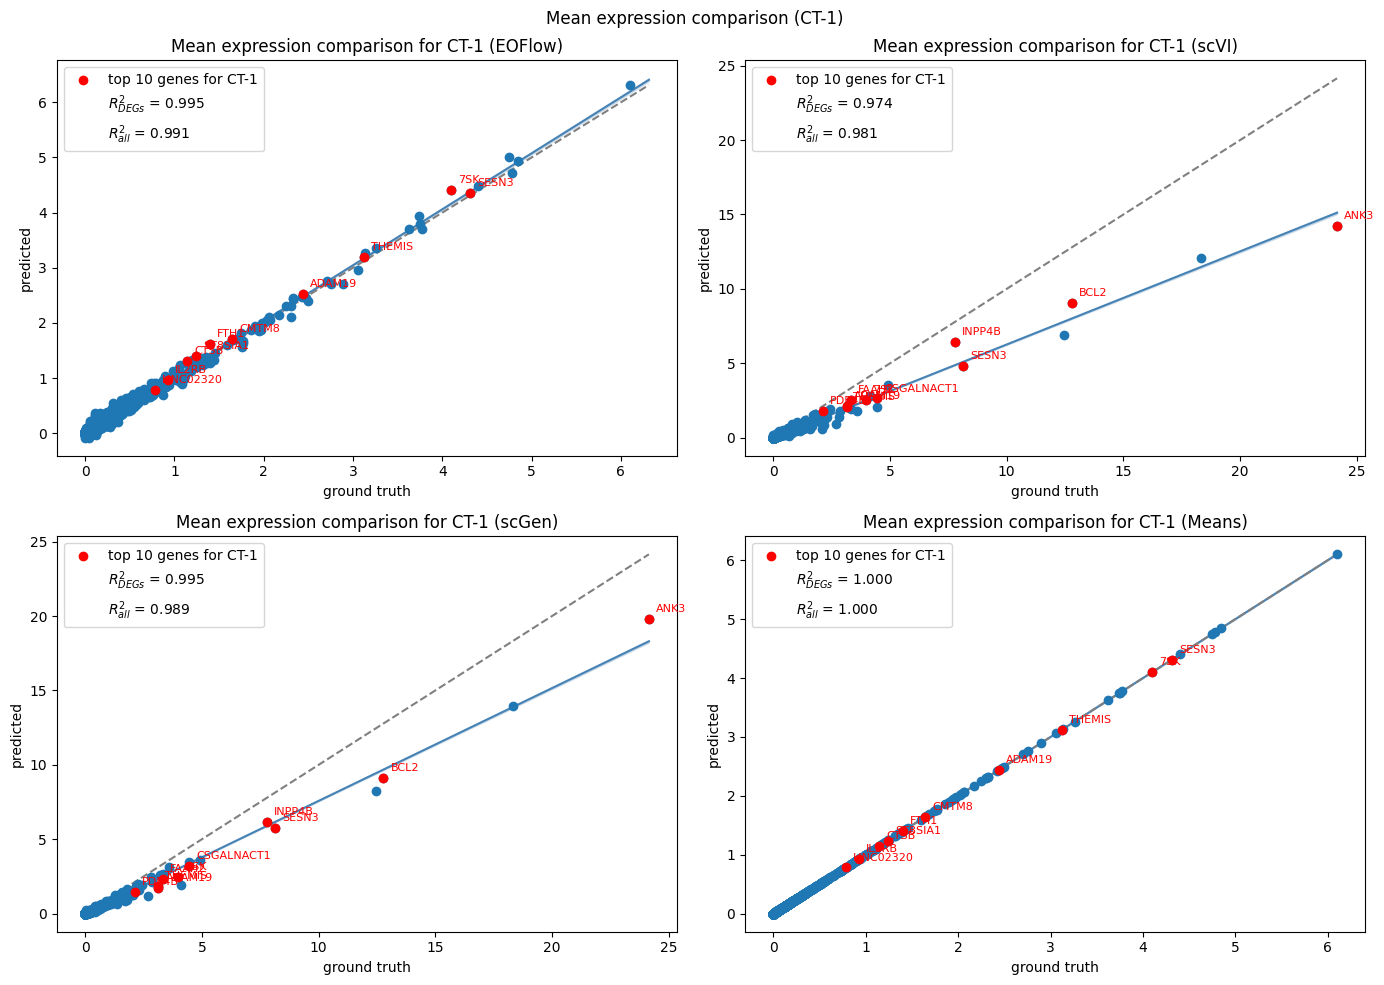

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_mean_expression_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=m["log1p_transform"],
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Mean expression comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mean_expression_comparison_{key}.png"), dpi=300)
plt.show()

### 3.4 Effect Size

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


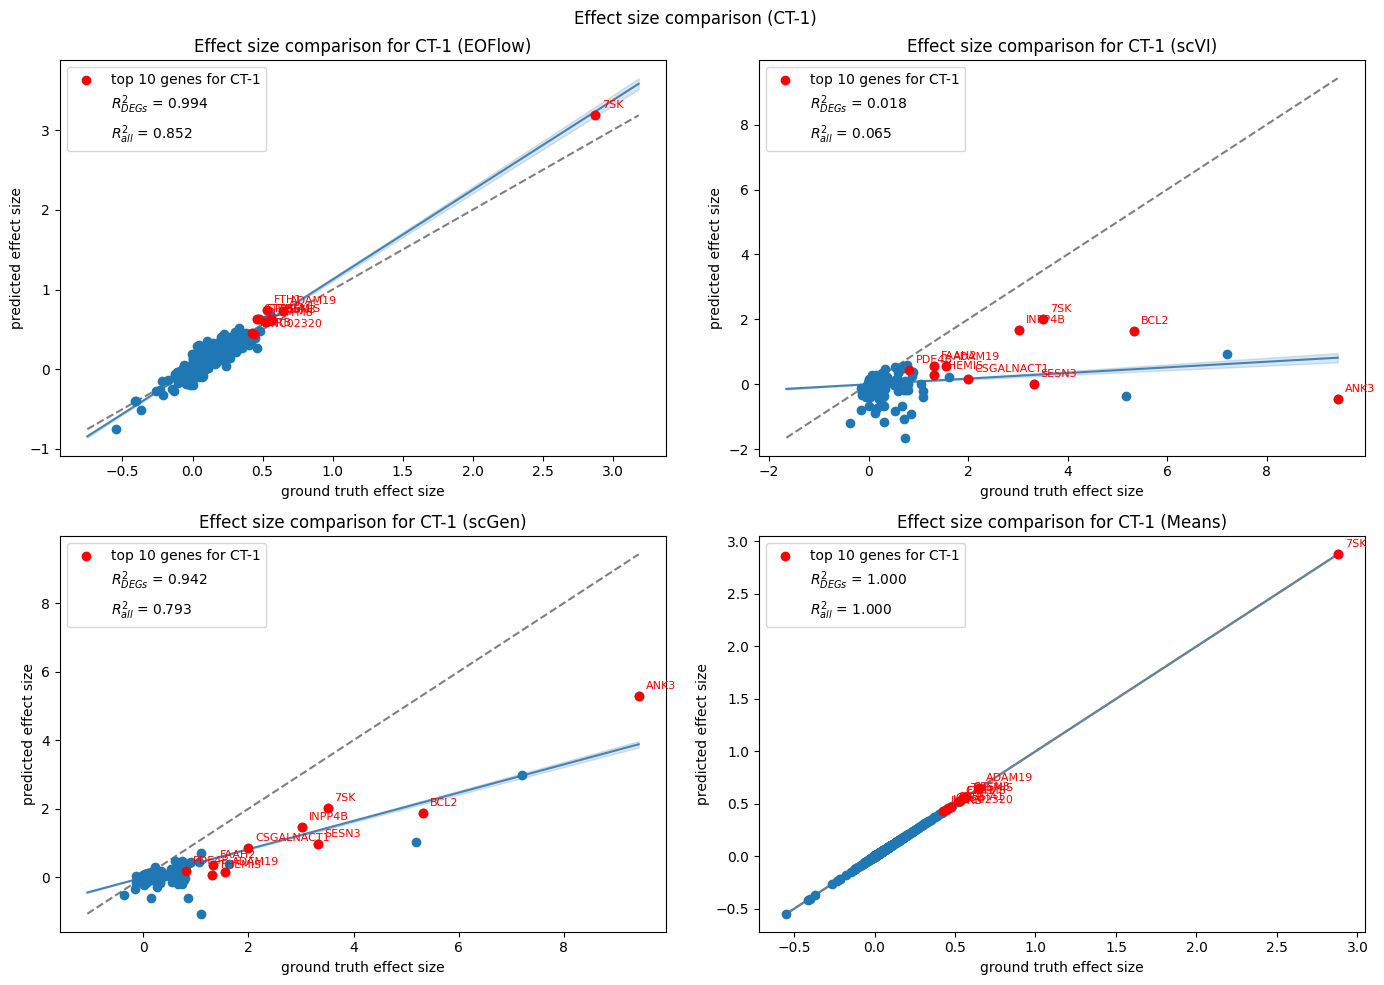

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_effect_size_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=m["log1p_transform"],
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Effect size comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"effect_size_comparison_{key}.png"), dpi=300)
plt.show()

### 3.5 Violin Plots

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:391: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(x, out=x)
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:391: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:391: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


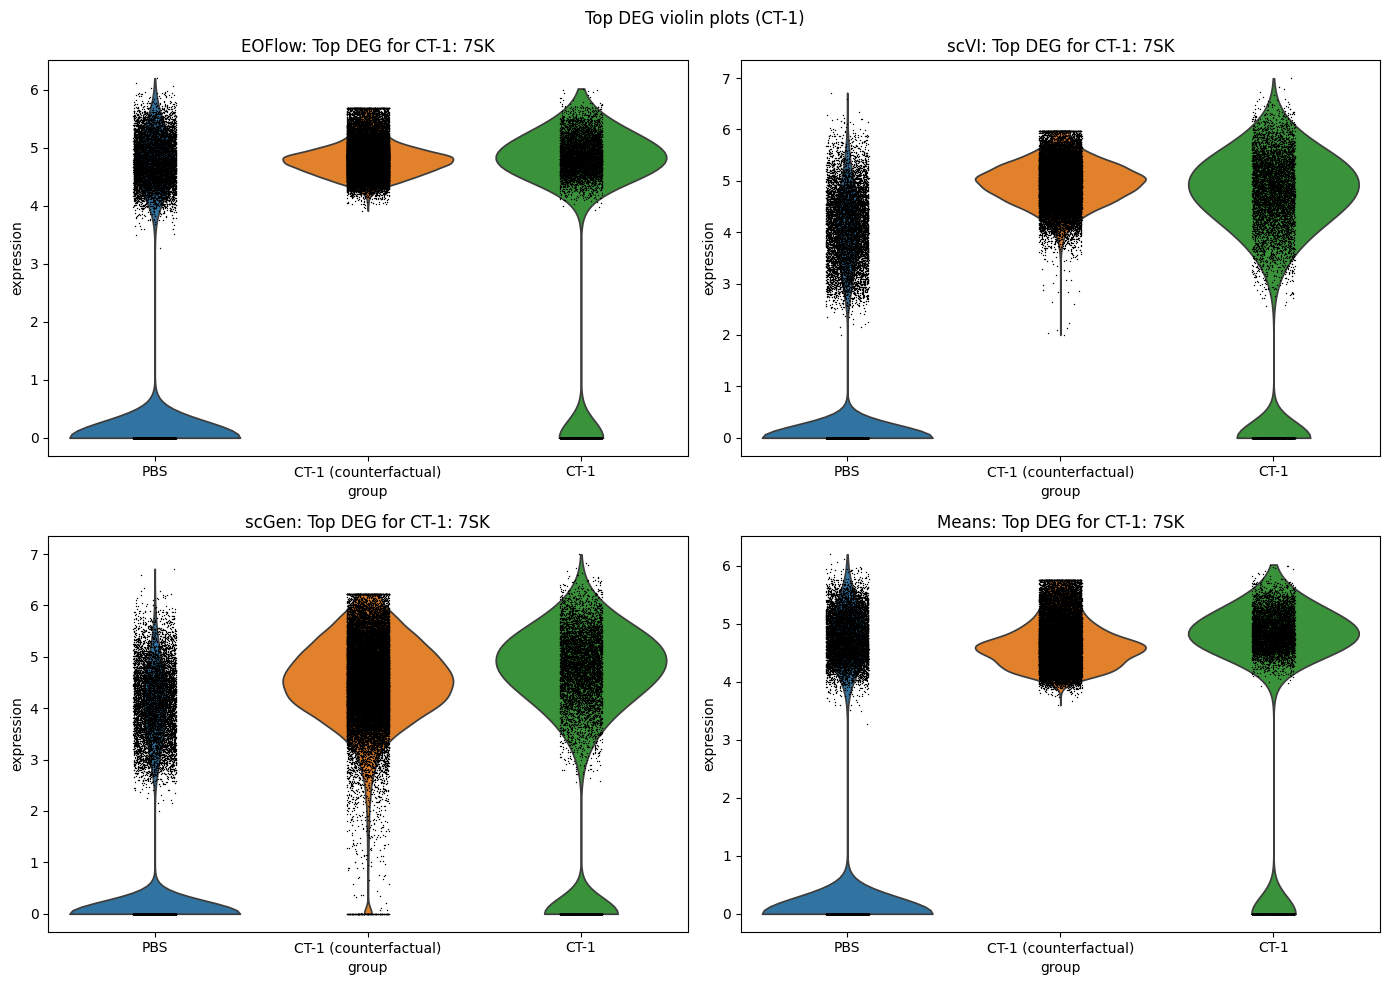

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_top_deg_violin(
        m["analyzer"],
        key=key,
        cfs_fn=m["cf_fn"],
        log1p_transform=True,
        ax=ax,
    )
    ax.set_title(f"{m['name']}: {ax.get_title()}")
fig.suptitle(f"Top DEG violin plots ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"violin_comparison_{key}.png"), dpi=300)
plt.show()

## 4. OOD Comparison

Evaluates all four models on the single `(cytokine=IL-2, cell_type=CD8 Memory)` combination that was held out *entirely* during training (no cell of this combo was ever seen) - mirroring the "## OOD" sections of `eoflow.ipynb`/`scvi.ipynb`/`scgen.ipynb`/`mean.ipynb`.

Requires `HOLDOUT_COMBO` (section 2) to be set so each method loads its holdout-trained checkpoint instead of its normal one - re-run the notebook from section 2 with that set before running these cells.

### 4.1 OOD Sampling

Both sampling strategies (Normal around the estimated mean, and shift real control cells) for every model, plus a `scoped_analyzer` restricting each model's `.adata` to just `CD8 Memory` so `labels_key` alone resolves to the held-out combo (see `INN_OOD.scoped_analyzer_for_combo`).

#### 4.1.1 EOFlow

In [ ]:
eoflow_key = eoflow_holdout_combo[eoflow_labels_key]

eoflow_adata_normal = inn_sample_leftout_combo_normal(
    model=eoflow_analyzer.model,
    combo_categories=eoflow_combo_categories,
    conditions=eoflow_combo_conditions,
    holdout_combo=eoflow_holdout_combo,
    condition_key=eoflow_labels_key,
    control_label=eoflow_control_label,
    cell_type_key="cell_type",
    n_samples=500,
    sigma=1.0,
    var=eoflow_analyzer.adata.var,
)

eoflow_adata_shift = inn_sample_leftout_combo_shift(
    model=eoflow_analyzer.model,
    adata=eoflow_analyzer.adata,
    combo_categories=eoflow_combo_categories,
    conditions=eoflow_combo_conditions,
    holdout_combo=eoflow_holdout_combo,
    condition_key=eoflow_labels_key,
    control_label=eoflow_control_label,
    cell_type_key="cell_type",
)

eoflow_scoped_analyzer = scoped_analyzer_for_combo(
    eoflow_analyzer,
    eoflow_holdout_combo,
    conditions=eoflow_combo_conditions,
    condition_key=eoflow_labels_key,
    cell_type_key="cell_type",
)

eoflow_predictions = {"Normal": eoflow_adata_normal, "Shift": eoflow_adata_shift}
print(
    "EOFlow real held-out cells: "
    f"{eoflow_scoped_analyzer.adata.obs[eoflow_labels_key].value_counts()[eoflow_key]}"
)

EOFlow real held-out cells: 34


#### 4.1.2 scVI

In [ ]:
scvi_key = scvi_holdout_combo[scvi_labels_key]

scvi_adata_normal = inn_sample_leftout_combo_normal(
    model=scvi_analyzer.model,
    combo_categories=scvi_combo_categories,
    conditions=combo_conditions,
    holdout_combo=scvi_holdout_combo,
    condition_key=scvi_labels_key,
    control_label=scvi_control_label,
    cell_type_key="cell_type",
    n_samples=500,
    sigma=1.0,
    var=scvi_analyzer.adata.var,
)

scvi_adata_shift = inn_sample_leftout_combo_shift(
    model=scvi_analyzer.model,
    adata=scvi_analyzer.adata,
    combo_categories=scvi_combo_categories,
    conditions=combo_conditions,
    holdout_combo=scvi_holdout_combo,
    condition_key=scvi_labels_key,
    control_label=scvi_control_label,
    cell_type_key="cell_type",
)

scvi_scoped_analyzer = scoped_analyzer_for_combo(
    scvi_analyzer,
    scvi_holdout_combo,
    conditions=combo_conditions,
    condition_key=scvi_labels_key,
    cell_type_key="cell_type",
)

scvi_predictions = {"Normal": scvi_adata_normal, "Shift": scvi_adata_shift}
print(
    "scVI real held-out cells: "
    f"{scvi_scoped_analyzer.adata.obs[scvi_labels_key].value_counts()[scvi_key]}"
)

scVI real held-out cells: 28


#### 4.1.3 scGen

Uses bespoke code rather than `INN_OOD`'s generic sampling functions, mirroring `scgen.ipynb` 4.1/4.2: the Normal strategy decodes via `module.generative()["px"]` directly (the same raw-count-scale decode `.predict()` uses internally - `forward()` would route through a different, log1p-only bridge), and the Shift strategy uses `SCGENMixturePriorWrapper.predict()`'s passthrough to `scgen.SCGEN.predict()` with `celltype_to_predict` - scGen's own official leave-one-combo-out pattern.

In [ ]:
scgen_key = scgen_holdout_combo[scgen_labels_key]

scgen_target_idx = scgen_combo_categories.index(
    "__".join(scgen_holdout_combo[c] for c in combo_conditions)
)
scgen_mean = scgen_analyzer.model.means[scgen_target_idx].detach()

scgen_z = scgen_mean.unsqueeze(0) + 1.0 * torch.randn(
    500, scgen_mean.shape[0], device=scgen_mean.device, dtype=scgen_mean.dtype
)
with torch.no_grad():
    scgen_x = (
        scgen_analyzer.model.module.generative(scgen_z)["px"].clamp(min=0).cpu().numpy()
    )

scgen_adata_normal = ad.AnnData(
    X=scgen_x,
    obs=pd.DataFrame({k: [v] * 500 for k, v in scgen_holdout_combo.items()}),
    var=scgen_adata.var.copy(),
)

scgen_adata_shift, scgen_delta = scgen_analyzer.model.predict(
    ctrl_key=scgen_control_label,
    stim_key=scgen_holdout_combo[scgen_labels_key],
    celltype_to_predict=scgen_holdout_combo["cell_type"],
)
# obs is copied from the real control cells .predict() started from - overwrite to
# reflect what these rows actually are: predictions at the held-out treatment
scgen_adata_shift.obs[scgen_labels_key] = scgen_holdout_combo[scgen_labels_key]

scgen_scoped_analyzer = scoped_analyzer_for_combo(
    scgen_analyzer,
    scgen_holdout_combo,
    conditions=combo_conditions,
    condition_key=scgen_labels_key,
    cell_type_key="cell_type",
)

scgen_predictions = {"Normal": scgen_adata_normal, "Shift": scgen_adata_shift}
print(
    "scGen real held-out cells: "
    f"{scgen_scoped_analyzer.adata.obs[scgen_labels_key].value_counts()[scgen_key]}"
)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
scGen real held-out cells: 28


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


#### 4.1.4 Means

In [ ]:
mean_key = mean_holdout_combo[mean_labels_key]

mean_adata_normal = mean_sample_leftout_combo_normal(
    mean_shifter,
    mean_analyzer.adata,
    holdout_combo=mean_holdout_combo,
    condition_key=mean_labels_key,
    control_label=mean_control_label,
    cell_type_key="cell_type",
    n_samples=500,
    sigma=1.0,
    var=mean_analyzer.adata.var,
)

mean_adata_shift = mean_sample_leftout_combo_shift(
    mean_shifter,
    mean_analyzer.adata,
    holdout_combo=mean_holdout_combo,
    condition_key=mean_labels_key,
    control_label=mean_control_label,
    cell_type_key="cell_type",
)

mean_scoped_analyzer = scoped_analyzer_for_combo(
    mean_analyzer,
    mean_holdout_combo,
    conditions=combo_conditions,
    condition_key=mean_labels_key,
    cell_type_key="cell_type",
)

mean_predictions = {"Normal": mean_adata_normal, "Shift": mean_adata_shift}
print(
    "Means real held-out cells: "
    f"{mean_scoped_analyzer.adata.obs[mean_labels_key].value_counts()[mean_key]}"
)

Means real held-out cells: 34


### 4.2 Registry

`log1p_transform` mirrors each model's own convention in its individual OOD notebook's mean-expression/effect-size cell (section 4.3/5.3 there): scVI compares its raw-count predictions/real cells on log-normalized scale, the rest are already log-space or explicitly kept raw.

In [ ]:
ood_models = [
    {
        "name": "EOFlow",
        "scoped_analyzer": eoflow_scoped_analyzer,
        "predictions": eoflow_predictions,
        "key": eoflow_key,
        "plot_dir": eoflow_plot_dir,
        "log1p_transform": False,
    },
    {
        "name": "scVI",
        "scoped_analyzer": scvi_scoped_analyzer,
        "predictions": scvi_predictions,
        "key": scvi_key,
        "plot_dir": scvi_plot_dir,
        "log1p_transform": True,
    },
    {
        "name": "scGen",
        "scoped_analyzer": scgen_scoped_analyzer,
        "predictions": scgen_predictions,
        "key": scgen_key,
        "plot_dir": scgen_plot_dir,
        "log1p_transform": False,
    },
    {
        "name": "Means",
        "scoped_analyzer": mean_scoped_analyzer,
        "predictions": mean_predictions,
        "key": mean_key,
        "plot_dir": mean_plot_dir,
        "log1p_transform": False,
    },
]

### 4.3 OOD MMD

Same 2x2-grid layout as section 3.2, but each panel now compares OOD sampling strategies against the real held-out-combo cells (`evaluate_leftout_combo_mmd`), with the control MMD (random split of real held-out cells) as the noise floor.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 34175.81it/s]


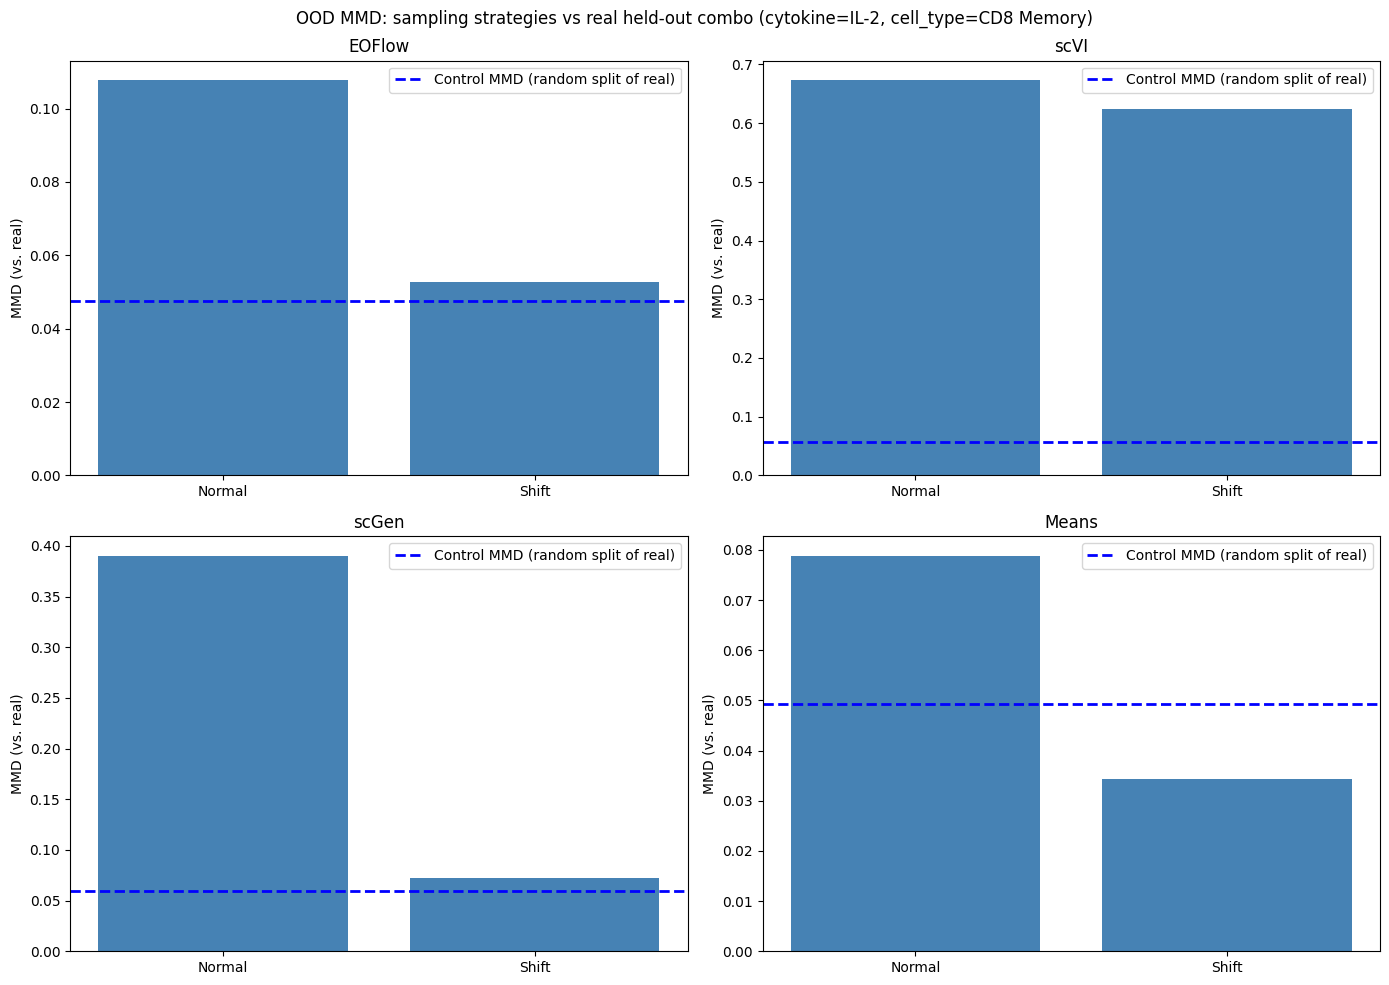

{'EOFlow': {'ctrl': 0.047681499272584915,
  'Normal': 0.10770606994628906,
  'Shift': 0.052739620208740234},
 'scVI': {'ctrl': 0.05636472627520561,
  'Normal': 0.6728439331054688,
  'Shift': 0.6232922673225403},
 'scGen': {'ctrl': 0.059164904057979584,
  'Normal': 0.38983726501464844,
  'Shift': 0.0724632740020752},
 'Means': {'ctrl': 0.04934652894735336,
  'Normal': 0.0787469744682312,
  'Shift': 0.03428518772125244}}

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ood_mmd_results = {}
for m, ax in zip(ood_models, axes.flat):
    results, ctrl_mmd = evaluate_leftout_combo_mmd(
        m["scoped_analyzer"], m["predictions"], key=m["key"], ax=ax
    )
    ax.set_title(m["name"])
    ood_mmd_results[m["name"]] = {"ctrl": ctrl_mmd, **results}
fig.suptitle("OOD MMD: sampling strategies vs real held-out combo (cytokine=IL-2, cell_type=CD8 Memory)")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mmd_comparison.png"), dpi=300)
plt.show()

ood_mmd_results

### 4.4 Which model is best?

Puts all four models' OOD MMD side by side in one plot (lower is better), with each model's own control MMD (random split of its real held-out cells) as a dashed noise-floor marker - a model that lands close to its own noise floor is doing about as well as the intrinsic variability of the data allows.

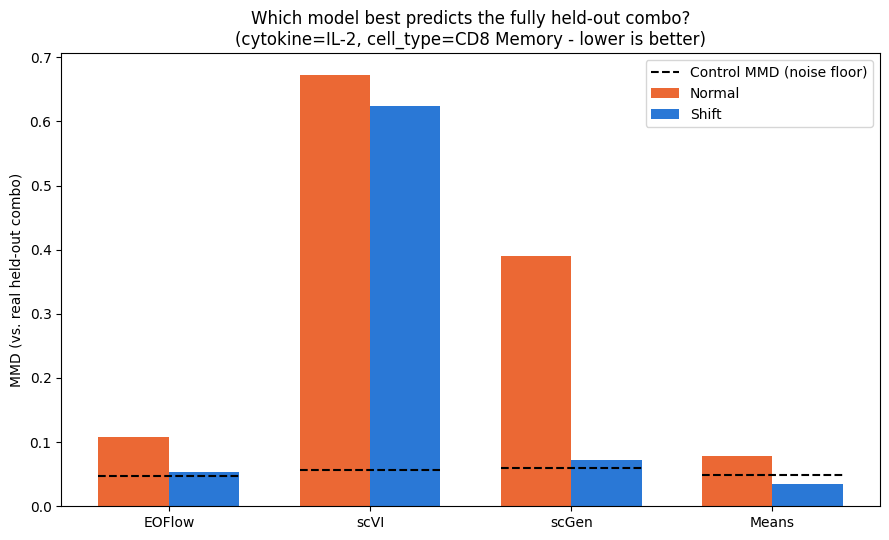

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ood_model_names = [m["name"] for m in ood_models]
ood_strategies = ["Normal", "Shift"]
ood_palette = {"Normal": "#eb6834", "Shift": "#2a78d6"}

x = np.arange(len(ood_model_names))
width = 0.35

for i, strategy in enumerate(ood_strategies):
    values = [ood_mmd_results[name][strategy] for name in ood_model_names]
    offset = (i - 0.5) * width
    ax.bar(x + offset, values, width, label=strategy, color=ood_palette[strategy])

for i, name in enumerate(ood_model_names):
    ax.hlines(
        ood_mmd_results[name]["ctrl"],
        x[i] - width,
        x[i] + width,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Control MMD (noise floor)" if i == 0 else None,
    )

ax.set_xticks(x)
ax.set_xticklabels(ood_model_names)
ax.set_ylabel("MMD (vs. real held-out combo)")
ax.set_title(
    "Which model best predicts the fully held-out combo?\n"
    "(cytokine=IL-2, cell_type=CD8 Memory - lower is better)"
)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mmd_summary.png"), dpi=300)
plt.show()

### 4.5 Mean Expression

Uses the Shift strategy only (encode/shift real control cells rather than draw fresh isotropic noise, so it carries over each cell's own structure) to keep this a 2x2 grid like section 3.3.

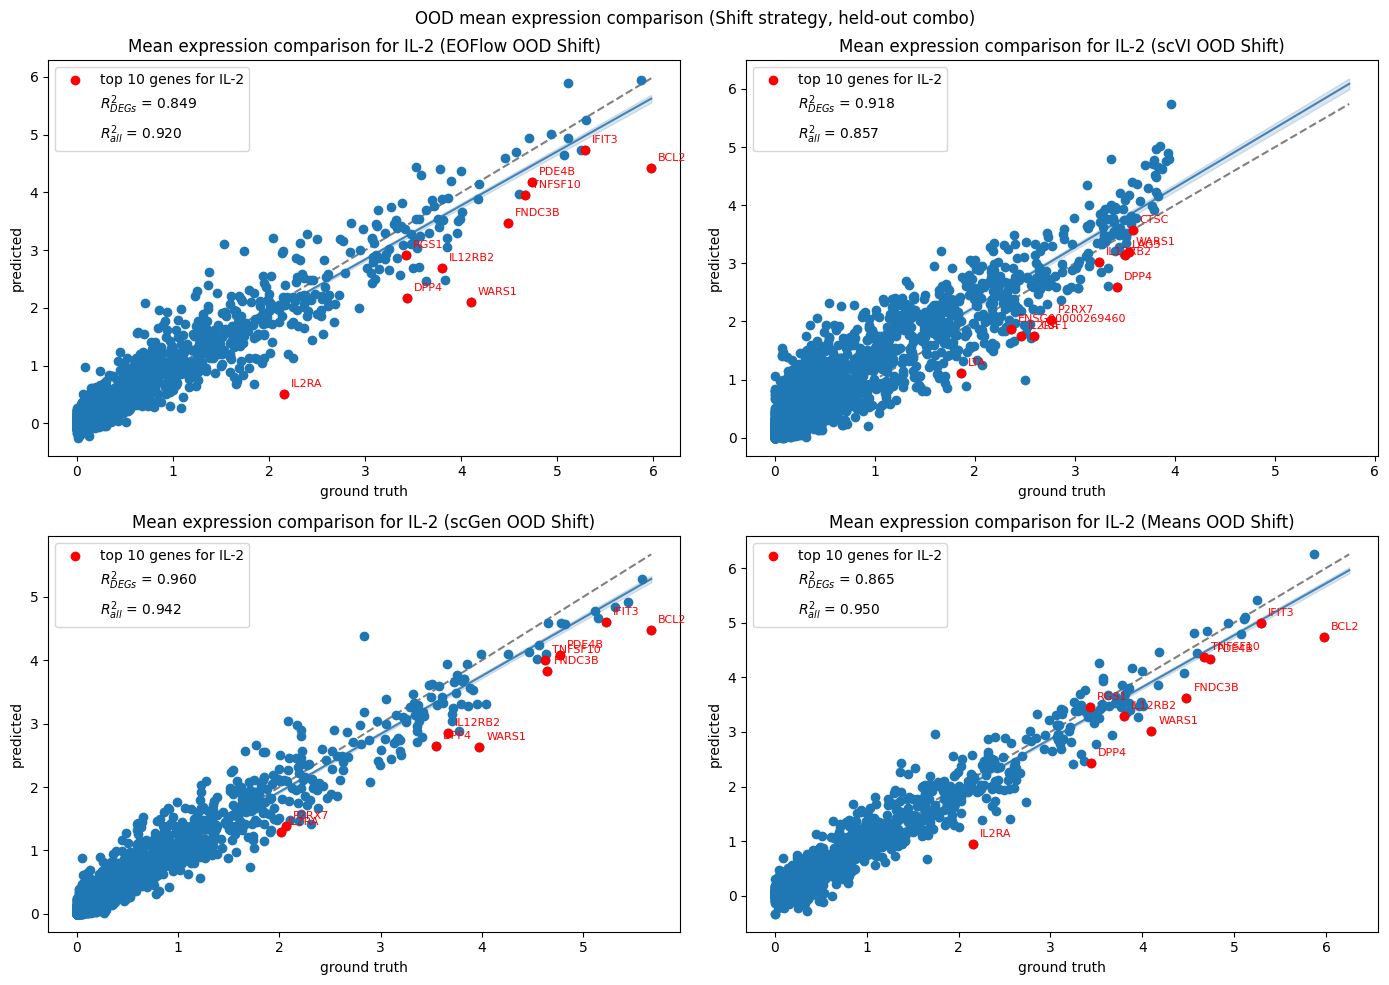

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(ood_models, axes.flat):
    cfs_fn = cfs_fn_from_adata(m["predictions"]["Shift"], source_label="Shift")
    plot_mean_expression_comparison(
        m["scoped_analyzer"],
        key=m["key"],
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=m["log1p_transform"],
        method=f"{m['name']} OOD Shift",
        ax=ax,
    )
fig.suptitle("OOD mean expression comparison (Shift strategy, held-out combo)")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mean_expression_comparison.png"), dpi=300)
plt.show()

### 4.6 Effect Size

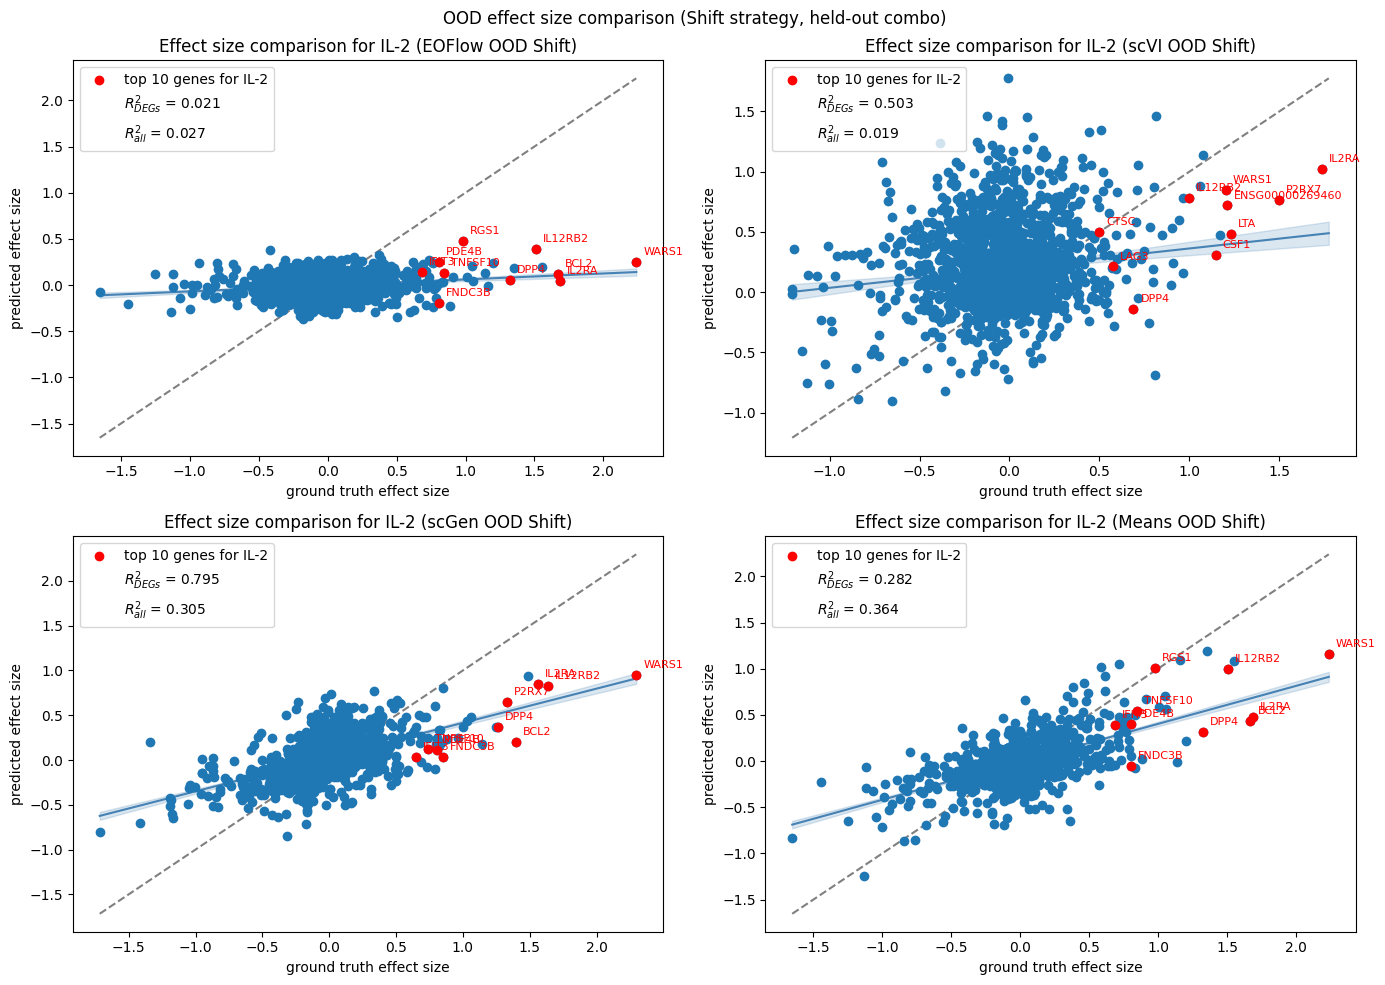

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(ood_models, axes.flat):
    cfs_fn = cfs_fn_from_adata(m["predictions"]["Shift"], source_label="Shift")
    plot_effect_size_comparison(
        m["scoped_analyzer"],
        key=m["key"],
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=m["log1p_transform"],
        method=f"{m['name']} OOD Shift",
        ax=ax,
    )
fig.suptitle("OOD effect size comparison (Shift strategy, held-out combo)")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_effect_size_comparison.png"), dpi=300)
plt.show()